# Pertemuan 6: Persiapan Data
### Preprocessing Dataset Titanic

| | |
|---|---|
| **Nama Lengkap** | Nisa Agustina Maesaroh |
| **NIM** | 240401070509 |
| **Kelas** | IF403 |


In [20]:
#1. lOAD & EDA Singkat
import pandas as pd,seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

#pilig kolom yang akan digunakan
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df = df[cols].copy()

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDistribusi target:')
print(df['survived'].value_counts(normalize=True).round(3))
# survived=0: ~61.6%, survived=1: ~38.4% — kelas tidak seimbang!

Shape: (891, 8)

Missing values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi target:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


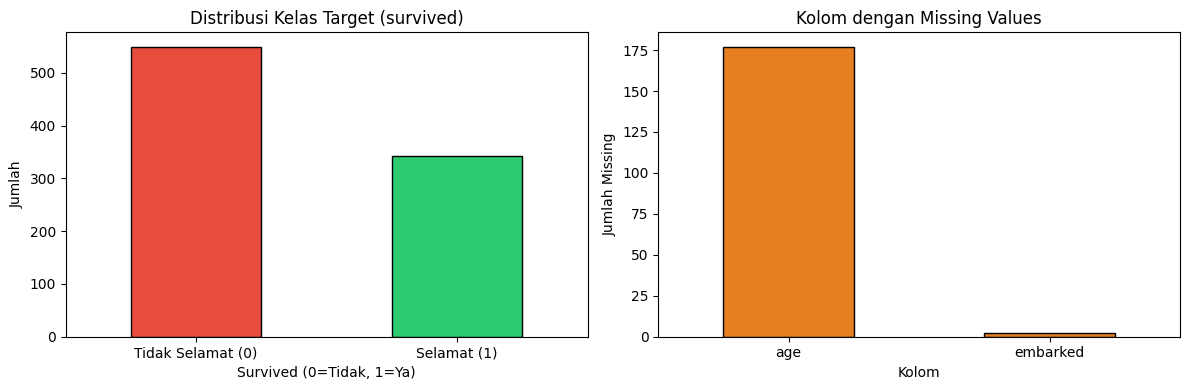


Info tipe data:
pclass        int64
sex             str
age         float64
sibsp         int64
parch         int64
fare        float64
embarked        str
survived      int64
dtype: object


In [21]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi target
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Kelas Target (survived)')
axes[0].set_xlabel('Survived (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(['Tidak Selamat (0)', 'Selamat (1)'], rotation=0)

# Missing values heatmap
missing = df.isnull().sum()
missing[missing > 0].plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Kolom dengan Missing Values')
axes[1].set_xlabel('Kolom')
axes[1].set_ylabel('Jumlah Missing')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\nInfo tipe data:')
print(df.dtypes)

In [22]:
#2. Handing Missing Values
#age: isi dengan median (robust terhadap outlier)
df['age'] = df['age'].fillna(df['age'].median())

#embarked: isi dengan modus (nilai paling sering)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing setelah handing:')
print(df.isnull().sum())
print(f'\nMedian age digunakan: {df["age"].median()}')
print(f'Modus embarked digunakan: S (Southampton)')

Missing setelah handing:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64

Median age digunakan: 28.0
Modus embarked digunakan: S (Southampton)


In [23]:
#3. Encoding Kategorikal
#One hot encoding untuk sex dan embarked
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True, dtype=int)

print('Kolom setelah encoding:')
print(df.columns.tolist())
# ['pclass','age','sibsp','parch','fare','survived',
#  'sex_male','embarked_Q','embarked_S']

print('\nContoh 5 baris pertama:')
print(df.head())

Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']

Contoh 5 baris pertama:
   pclass   age  sibsp  parch     fare  survived  sex_male  embarked_Q  \
0       3  22.0      1      0   7.2500         0         1           0   
1       1  38.0      1      0  71.2833         1         0           0   
2       3  26.0      0      0   7.9250         1         0           0   
3       1  35.0      1      0  53.1000         1         0           0   
4       3  35.0      0      0   8.0500         0         1           0   

   embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  


In [24]:
#4. Train-Test Split
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #proporsi kelas terjaga
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test: {X_test.shape[0]} baris')
print('\nProporsi survived di Train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporsi survived di Test:')
print(y_test.value_counts(normalize=True).round(3))

Train: 712 baris
Test: 179 baris

Proporsi survived di Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


In [25]:
#5. Feature Scaling
from sklearn.preprocessing import StandardScaler

#hanya kolom numeric yang perlu di scale
#kolom biner (sex_male, embarked_Q, embarked_S) tidak perlu
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

#fit_transform pada training set (belajar μ dan σ dari sini)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
#fit_transform pada training set (belajar μ dan σ dari training)
X_test[num_cols] = scaler.transform(X_test[num_cols])


print('Mean scaler (dari train):', scaler.mean_.round(2))
print('Std scaler (dari train):', scaler.scale_.round(2))
print()
print('Contoh X_train setelah scaling:')
print(X_train.head(3).round(3))
print('\nData siap dilatih model Machine Learning!')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')

Mean scaler (dari train): [ 2.31 29.46  0.49  0.39 31.82]
Std scaler (dari train): [ 0.83 13.03  1.06  0.84 48.03]

Contoh X_train setelah scaling:
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1

Data siap dilatih model Machine Learning!
X_train: (712, 8), y_train: (712,)
X_test : (179, 8), y_test : (179,)


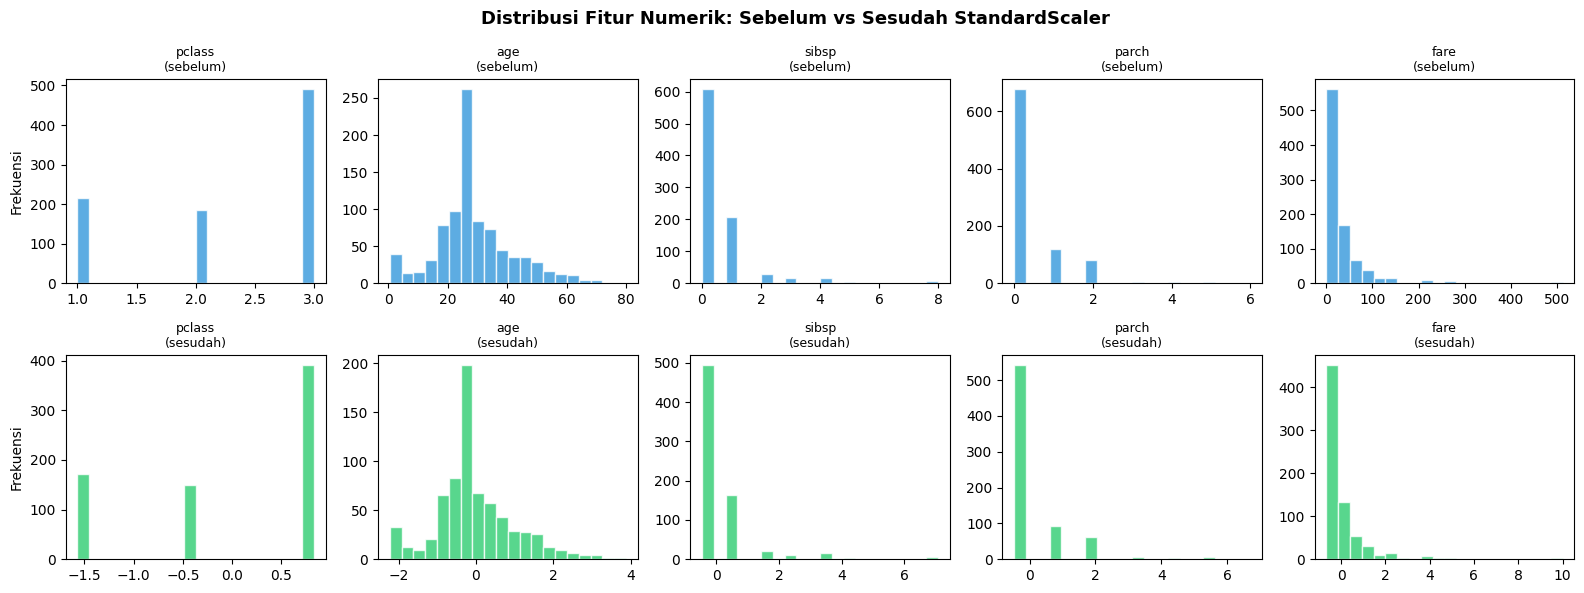

Pipeline preprocessing selesai! Data siap untuk pemodelan.


In [26]:
# Visualisasi: distribusi fitur sebelum vs sesudah scaling
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Distribusi Fitur Numerik: Sebelum vs Sesudah StandardScaler', fontsize=13, fontweight='bold')

# Buat ulang data sebelum scaling untuk perbandingan
X_before = df.drop('survived', axis=1)

for i, col in enumerate(num_cols):
    # Sebelum scaling
    axes[0, i].hist(X_before[col], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(sebelum)', fontsize=9)
    axes[0, i].set_ylabel('Frekuensi' if i == 0 else '')

    # Sesudah scaling
    axes[1, i].hist(X_train[col], bins=20, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(sesudah)', fontsize=9)
    axes[1, i].set_ylabel('Frekuensi' if i == 0 else '')

plt.tight_layout()
plt.show()
print('Pipeline preprocessing selesai! Data siap untuk pemodelan.')

# Kesimpulan

## Apa yang Dipelajari
Mempelajari pipeline preprocessing: encoding variabel kategorik, imputasi missing values, dan scaling fitur numerik menggunakan StandardScaler pada dataset Titanic.

## Temuan Utama
StandardScaler mengubah distribusi fitur numerik sehingga memiliki mean=0 dan std=1, yang penting untuk algoritma berbasis jarak. Visualisasi sebelum vs sesudah scaling membuktikan perubahan skala tanpa mengubah bentuk distribusi.

## Keterbatasan & Pertanyaan
Pipeline belum diintegrasikan dengan model ML secara end-to-end. Pertanyaan: apakah normalisasi (MinMaxScaler) lebih cocok daripada standardisasi untuk data dengan distribusi non-normal?